IPN - CIC
Luis Angel Rojo Chavez

# Iris

Número de componentes seleccionados para Iris: 2
Varianza total explicada: 95.93%

==================== Resultados para Iris ====================

  Classifier  Components  Sensitivity_Original  Specificity_Original  BalancedAccuracy_Original  Sensitivity_PCA  Specificity_PCA  BalancedAccuracy_PCA  Improved
        k-NN           2                0.9333                0.9667                     0.9333           0.9333           0.9667                0.9333     False
  GaussianNB           2                0.9778                0.9889                     0.9778           0.8222           0.9111                0.8222     False
DecisionTree           2                0.9333                0.9667                     0.9333           0.8444           0.9222                0.8444     False
RandomForest           2                0.9556                0.9778                     0.9556           0.8667           0.9333                0.8667     False
    AdaBoost           2                0.9

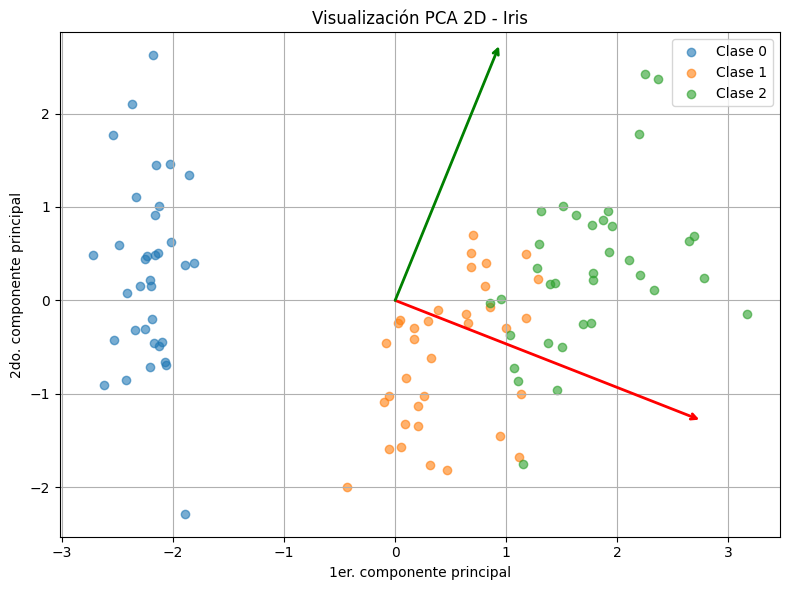

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score, balanced_accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import copy

def draw_vector(v0, v1, c, ax=None):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->', linewidth=2, shrinkA=0, shrinkB=0, color=c)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

def evaluar_conjunto(X, y, dataset_name="Dataset"):
    seed = 7
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=seed)

    scaler = StandardScaler().fit(X_train)
    X_train_std = scaler.transform(X_train)
    X_test_std = scaler.transform(X_test)

    pca_full = PCA().fit(X_train_std)
    n_components = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.9) + 1
    pca_final = PCA(n_components=n_components).fit(X_train_std)
    X_train_pca = pca_final.transform(X_train_std)
    X_test_pca = pca_final.transform(X_test_std)

    models = {
        'k-NN': KNeighborsClassifier(),
        'GaussianNB': GaussianNB(),
        'DecisionTree': DecisionTreeClassifier(random_state=seed),
        'RandomForest': RandomForestClassifier(random_state=seed),
        'AdaBoost': AdaBoostClassifier(random_state=seed)
    }

    def metrics(y_true, y_pred):
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred)
        n_classes = cm.shape[0]
        specificities = []

        for i in range(n_classes):
            TP = cm[i, i]
            FP = cm[:, i].sum() - TP
            FN = cm[i, :].sum() - TP
            TN = cm.sum() - (TP + FP + FN)
            spec = TN / (TN + FP) if (TN + FP) > 0 else 0
            specificities.append(spec)

        specificity = np.mean(specificities)
        sensitivity = recall_score(y_true, y_pred, average='micro')
        balanced = balanced_accuracy_score(y_true, y_pred)
        return sensitivity, specificity, balanced

    results = []
    for name, model in models.items():
        model_orig = copy.deepcopy(model)
        model_pca = copy.deepcopy(model)

        model_orig.fit(X_train_std, y_train)
        r1, s1, b1 = metrics(y_test, model_orig.predict(X_test_std))

        model_pca.fit(X_train_pca, y_train)
        r2, s2, b2 = metrics(y_test, model_pca.predict(X_test_pca))

        results.append({
            'Classifier': name,
            'Components': n_components,
            'Sensitivity_Original': round(r1, 4),
            'Specificity_Original': round(s1, 4),
            'BalancedAccuracy_Original': round(b1, 4),
            'Sensitivity_PCA': round(r2, 4),
            'Specificity_PCA': round(s2, 4),
            'BalancedAccuracy_PCA': round(b2, 4),
            'Improved': b2 > b1
        })

    print(f"Número de componentes seleccionados para {dataset_name}: {n_components}")
    print(f"Varianza total explicada: {round(np.sum(pca_full.explained_variance_ratio_[:n_components]) * 100, 2)}%")

    results_df = pd.DataFrame(results)
    print(f"\n{'='*20} Resultados para {dataset_name} {'='*20}\n")
    print(results_df.to_string(index=False))

    # PCA 2D
    pca_vis = PCA(n_components=2).fit(X_train_std)
    X_vis = pca_vis.transform(X_train_std)
    mean_vector = X_train_std.mean(axis=0).reshape(1, -1)
    mean_2D = pca_vis.transform(mean_vector)[0]

    plt.figure(figsize=(8, 6))
    for label in np.unique(y_train):
        plt.scatter(X_vis[y_train == label, 0], X_vis[y_train == label, 1], label=f"Clase {label}", alpha=0.6)

    colors = ['r', 'g']
    for i in range(2):
        v_2D = pca_vis.components_[i, :2] * 3 * np.sqrt(pca_vis.explained_variance_[i])
        draw_vector(mean_2D, mean_2D + v_2D, colors[i])

    plt.xlabel('1er. componente principal')
    plt.ylabel('2do. componente principal')
    plt.title(f'Visualización PCA 2D - {dataset_name}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{dataset_name}.png", format='png')
    plt.show()


# Iris
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
evaluar_conjunto(X, y, dataset_name="Iris")


# Heart

Número de componentes seleccionados para heart: 10
Varianza total explicada: 90.85%

==================== Resultados para heart ====================

  Classifier  Components  Sensitivity_Original  Specificity_Original  BalancedAccuracy_Original  Sensitivity_PCA  Specificity_PCA  BalancedAccuracy_PCA  Improved
        k-NN          10                0.8519                0.8528                     0.8528           0.7778           0.7750                0.7750     False
  GaussianNB          10                0.8272                0.8278                     0.8278           0.8519           0.8500                0.8500      True
DecisionTree          10                0.7284                0.7361                     0.7361           0.7531           0.7583                0.7583      True
RandomForest          10                0.8272                0.8250                     0.8250           0.7901           0.7917                0.7917     False
    AdaBoost          10                

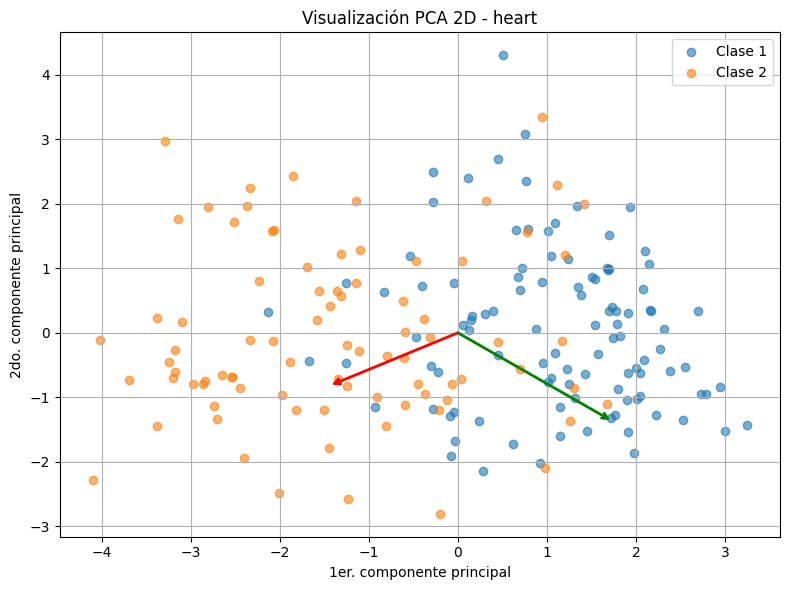

In [ ]:
# Heart

import pandas as pd

# heart.dat
heart_df = pd.read_csv("heart.dat", header=None, delimiter=',', comment='@')
X_heart = heart_df.iloc[:, :-1].values  # Todas las columnas menos la última
y_heart = heart_df.iloc[:, -1].values   # Última columna es la clase

# led7digit.dat
led_df = pd.read_csv("led7digit.dat", header=None, delimiter=',', comment='@')
X_led = led_df.iloc[:, :-1].values
y_led = led_df.iloc[:, -1].values

evaluar_conjunto(X_heart, y_heart, dataset_name="heart")

# Led7Digit

Número de componentes seleccionados para led7digit: 6
Varianza total explicada: 93.72%

==================== Resultados para led7digit ====================

  Classifier  Components  Sensitivity_Original  Specificity_Original  BalancedAccuracy_Original  Sensitivity_PCA  Specificity_PCA  BalancedAccuracy_PCA  Improved
        k-NN           6                0.6600                0.9621                     0.6549           0.7000           0.9667                0.6982      True
  GaussianNB           6                0.6467                0.9611                     0.6553           0.7467           0.9717                0.7422      True
DecisionTree           6                0.7133                0.9682                     0.7109           0.7067           0.9675                0.7056     False
RandomForest           6                0.7000                0.9667                     0.6973           0.7067           0.9674                0.7054      True
    AdaBoost           6         

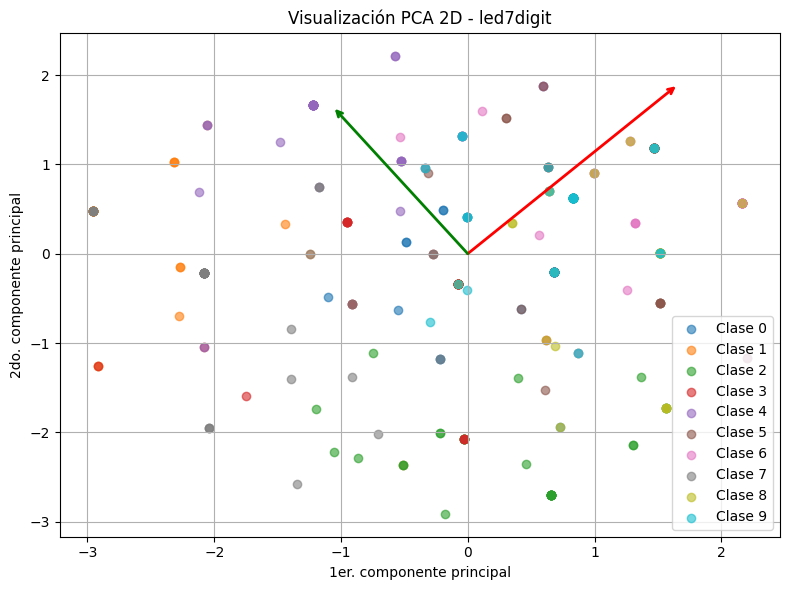

In [ ]:
evaluar_conjunto(X_led, y_led, dataset_name="led7digit")